Electrolyte Optimizer — Phase 1
## Solid-State Battery Electrolyte Discovery Pipeline
**Project:** Conditional Molecular Generation for Solid-State Battery Electrolytes  


This notebook implements a complete ETL pipeline to extract, validate,
and featurize solid-state electrolyte candidates from the Materials Project
database, trains an XGBoost surrogate model to predict band gap, and
visualizes the chemical space using UMAP.

## Section 1 — Setup
Mount Google Drive, install dependencies, configure API keys and file paths.

In [2]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# install packages
!pip install pymatgen matminer mp-api tqdm -q
! pip install mp-api -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━

In [4]:
# imports
from mp_api.client import MPRester
from pymatgen.core import Composition, Structure
from google.colab import userdata
from pathlib import Path
import json, os








In [17]:
# Configuration
API_KEY = userdata.get('MP_API_KEY')
PROJECT_ROOT = "/content/drive/MyDrive/electrolyte_optimizer"
RAW_DATA_PATH = f"{PROJECT_ROOT}/data/raw/sse_raw.json"
RESULTS_PATH = "/content/drive/MyDrive/electrolyte_optimizer/results"
Path(RESULTS_PATH).mkdir(parents=True, exist_ok=True)
Path(f"{PROJECT_ROOT}/data/raw").mkdir(parents=True, exist_ok=True)



Results folder ready: /content/drive/MyDrive/electrolyte_optimizer/results


## Section 2 — Extract
Query the Materials Project API for Li-containing materials across
5 chemical families: oxides, sulfides, phosphates, halides, and borates.

**Why separate queries per family:** Each family has different thermodynamic
stability norms. Sulfides tolerate higher hull energy (0.10 eV/atom)
than oxides (0.05 eV/atom). A single unified query would apply
incorrect thresholds to all families.

**Output:** 21,764 raw entries saved to Drive as JSON.


In [6]:
# extract
def extract_data(api_key):
  with MPRester(api_key) as mpr:
    results = mpr.materials.summary.search(
        elements = ['Li'],
        fields = ['material_id', 'formula_pretty', 'energy_above_hull', 'structure', 'band_gap', 'nsites']
    )



  print(f"Total data obtained:, {len(results)}")

  return results





raw_entries = extract_data(API_KEY)

Retrieving SummaryDoc documents:   0%|          | 0/21764 [00:00<?, ?it/s]

Total data obtained:, 21764


In [7]:
import json

# save raw_entries to Drive
save_path = "/content/drive/MyDrive/electrolyte_optimizer/data/raw/sse_raw.json"

records = []
for entry in raw_entries:
    records.append({
        "material_id":        entry.material_id,
        "formula_pretty":     entry.formula_pretty,
        "band_gap":           entry.band_gap,
        "energy_above_hull":  entry.energy_above_hull,
        "nsites":             entry.nsites,
        "structure":          entry.structure.as_dict(),
    })

with open(save_path, "w") as f:
    json.dump(records, f)

print(f"Saved {len(records):,} entries to Drive")

Saved 21,764 entries to Drive


In [8]:
# inspecting the data first
first = raw_entries[0]
print(first.material_id)
print(first.formula_pretty)
print(first.energy_above_hull)
print(first.structure)

mp-1018134
Li
0.0
Full Formula (Li3)
Reduced Formula: Li
abc   :   3.078674   3.078672   7.665408
angles:  78.415314  78.415312  59.999997
pbc   :       True       True       True
Sites (3)
  #  SP            a         b         c    magmom
---  ----  ---------  --------  --------  --------
  0  Li     0.777028  0.777028  0.668915         0
  1  Li     0.222972  0.222972  0.331085         0
  2  Li    -0         0         0               -0


In [9]:
import pandas as pd
# create a summary doc
records = []
for entry in raw_entries:
  records.append({
      'material_id': entry.material_id,
      'formula_pretty': entry.formula_pretty,
      'energy_above_hull': entry.energy_above_hull,
      'structure': entry.structure,
      'band_gap': entry.band_gap,
      'nsites': entry.nsites,

  })




df = pd.DataFrame(records)
df.head()


,material_id,formula_pretty,energy_above_hull,structure,band_gap,nsites
0,mp-1018134,Li,0.000000,"[[-4.61800863 -2.66620944 -4.98775184] Li, [-1...",0.0,3
1,mp-1063005,Li,0.015671,"[[0. 0. 0.] Li, [-2.47408653 1.42882943 -1.44...",0.0,3
2,mp-10173,Li,0.005988,[[-1.18073136e-06 1.74059460e+00 1.27708055e...,0.0,2
3,mp-976411,Li,0.005889,[[0.00000000e+00 0.00000000e+00 1.02162077e-05...,0.0,4
4,mp-604313,Li,0.261799,"[[3.89571093 0.55872882 2.78594769] Li, [1.668...",0.0,4


## Section 3 — Exploratory Data Analysis
Understand the dataset before writing any filters. Every threshold
in the Transform stage is justified by what we find here.

**Key findings:**
- 29.9% of materials are metals (band_gap = 0.0) — irrelevant for SSE
- 75% of materials have hull energy below 0.094 eV/atom
- Band gap distribution is right-skewed — mean 1.28, median 0.74
- No strong correlations between features (max correlation: 0.21)

In [10]:

# basic shape and missing values
df.shape


(21764, 6)

In [11]:
df.isnull().sum()

,0
material_id,0
formula_pretty,0
energy_above_hull,0
structure,0
band_gap,0
nsites,0


In [12]:
df.dtypes

,0
material_id,object
formula_pretty,object
energy_above_hull,float64
structure,object
band_gap,float64
nsites,int64


In [13]:
df["band_gap"].value_counts()

,count
band_gap,
0.0000,6517
0.0001,8
0.0002,7
0.0001,6
0.0003,5
...,...
5.1568,1
2.9007,1
4.5497,1


In [14]:
print(df["band_gap"].value_counts().head(10))
print(f"\nMaterials with band_gap = 0.0 : {(df['band_gap'] == 0.0).sum()}")
print(f"That is {(df['band_gap'] == 0.0).sum() / len(df) * 100:.1f}% of your data")

band_gap
0.0000    6517
0.0001       8
0.0002       7
0.0001       6
0.0003       5
0.0004       5
0.0009       5
0.0040       5
0.0465       4
0.0705       4
Name: count, dtype: int64

Materials with band_gap = 0.0 : 6517
That is 29.9% of your data


In [15]:
# Descriptive statistics
df.describe()

,energy_above_hull,band_gap,nsites
count,21764.000000,21764.000000,21764.000000
mean,0.136564,1.282945,34.573194
std,0.414778,1.477749,25.375162
min,0.000000,0.000000,1.000000
25%,0.025657,0.000000,16.000000
50%,0.060032,0.738400,28.000000
75%,0.094106,2.220475,44.000000
max,7.607590,8.716100,392.000000


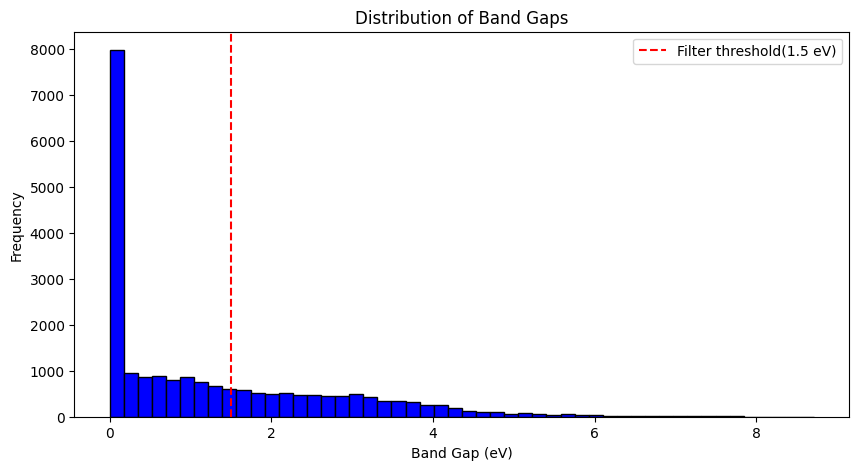

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.hist(df["band_gap"], bins = 50, color = "blue", edgecolor = "black")
plt.axvline(x= 1.5, color = 'red', linestyle = '--', label = 'Filter threshold(1.5 eV)')
plt.xlabel("Band Gap (eV)")
plt.ylabel("Frequency")
plt.title("Distribution of Band Gaps")
plt.legend()
plt.savefig(f"{RESULTS_PATH}/band_gap_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

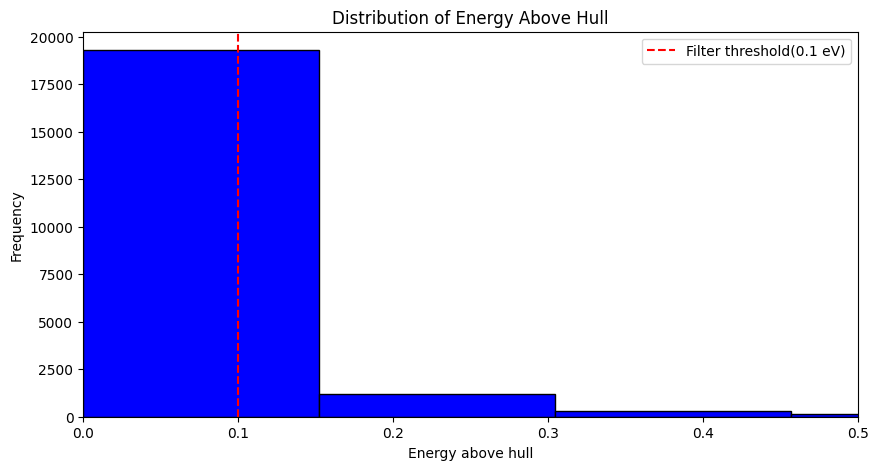

In [20]:
plt.figure(figsize=(10,5))
plt.hist(df["energy_above_hull"], bins=50, color="blue", edgecolor="black")
plt.axvline(x=0.1, color='red', linestyle='--', label='Filter threshold(0.1 eV)')
plt.xlabel("Energy above hull")
plt.ylabel("Frequency")
plt.title("Distribution of Energy Above Hull")
plt.xlim(0, 0.5)
plt.legend()
plt.savefig(f"{RESULTS_PATH}/hull_energy_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

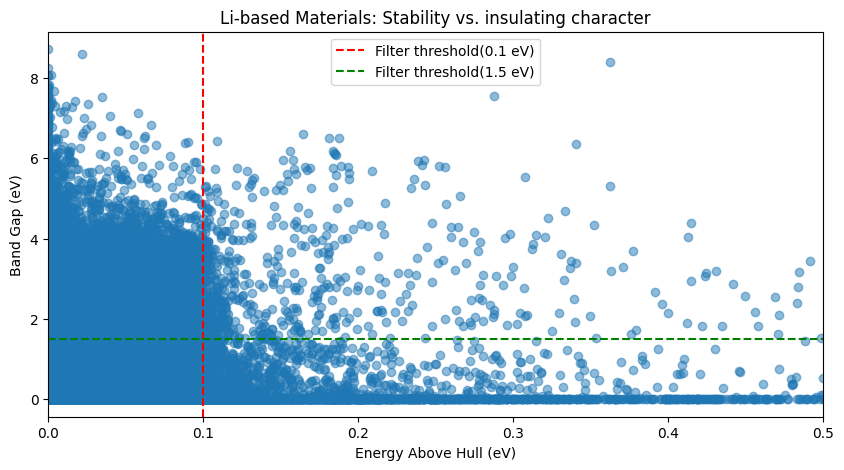

In [22]:
# scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(df["energy_above_hull"], df["band_gap"], alpha=0.5)
plt.axvline(x=0.1, color='red', linestyle='--', label='Filter threshold(0.1 eV)')
plt.axhline(y=1.5, color='green', linestyle='--', label='Filter threshold(1.5 eV)')
plt.xlabel("Energy Above Hull (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Li-based Materials: Stability vs. insulating character")
plt.xlim(0, 0.5)
plt.legend()
plt.savefig(f"{RESULTS_PATH}/stability_vs_bandgap.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
cond1 = df["band_gap"] > 1.5
cond2 = df["energy_above_hull"] < 0.1
cond3 = df["nsites"] >= 2
cond4 = df["nsites"] <= 50

mask = cond1 & cond2 & cond3 & cond4
candidates = df[mask]
print(f"Total number of materials : {len(df)}")
print(f"Number of SSE candidates : {len(candidates)}")
print(f"Percentage of SSE candidates : {len(candidates) / len(df) * 100:.1f}%")
print(f"Percentage of Materials removed by both filters : {(len(df) - len(candidates))/ len(df) * 100:.1f}")

Total number of materials : 21764
Number of SSE candidates : 5033
Percentage of SSE candidates : 23.1%
Percentage of Materials removed by both filters : 76.9


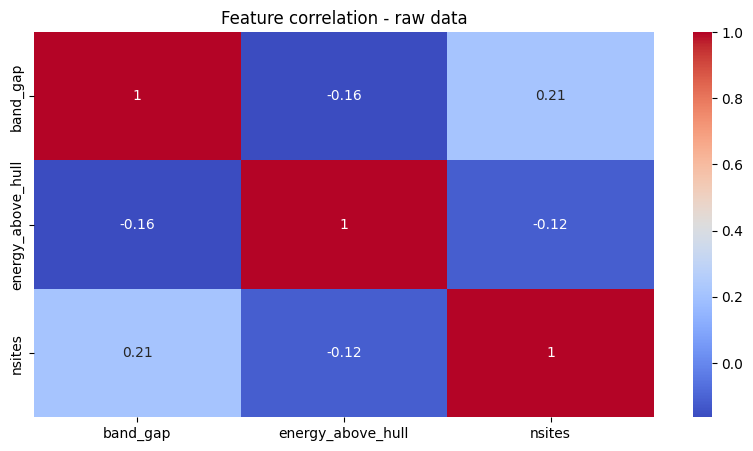

In [50]:
# Heatmap
import seaborn as sns
plt.figure(figsize=(10, 5))
corr = df[['band_gap', 'energy_above_hull',"nsites"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature correlation - raw data")
plt.savefig(f"{RESULTS_PATH}/Feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Transform
Filter raw entries to genuine SSE candidates using thresholds
derived from EDA. Enrich with derived features.

**Four filters applied:**

| Filter | Threshold | Justification |
|--------|-----------|---------------|
| Band gap | > 1.5 eV | Removes metals and semiconductors |
| Hull energy | < 0.1 eV/atom | Keeps thermodynamically stable materials |
| Unit cell size | 2 to 50 atoms | Removes single atoms and overly complex structures |
| Li fraction | > 0.10 | Ensures meaningful Li content for conduction |

**Result:** 21,764 → 4,017 candidates (18.4% retention)

In [27]:
# Transforming the data

def transform_data (df) :
  df["Li_fraction"] = df["formula_pretty"].apply(lambda x: Composition(x).get_atomic_fraction("Li"))
  print(f"Before filtering : {len(df)} rows")
  # filter 1
  df = df[df["band_gap"] >1.5]
  #filter 2
  df = df[df["energy_above_hull"] < 0.1]
  #filter 3
  df = df[(df["nsites"] >= 2) & (df["nsites"] <= 50)]
  # filter 4
  df = df[df["Li_fraction"] >= 0.10]
  print(f"After filtering : {len(df)} rows")
  return df

clean_df = transform_data(df)





Before filtering : 21764 rows
After filtering : 4017 rows


In [28]:
df_original = pd.DataFrame(records)  # reload original

total = len(df_original)
after_bg    = len(df_original[df_original["band_gap"] > 1.5])
after_hull  = len(df_original[(df_original["band_gap"] > 1.5) &
                               (df_original["energy_above_hull"] < 0.1)])
after_sites = len(df_original[(df_original["band_gap"] > 1.5) &
                               (df_original["energy_above_hull"] < 0.1) &
                               (df_original["nsites"] >= 2) &
                               (df_original["nsites"] <= 50)])

print(f"Started with        : {total:,}")
print(f"After band gap      : {after_bg:,}  removed {total - after_bg:,}")
print(f"After hull energy   : {after_hull:,}  removed {after_bg - after_hull:,}")
print(f"After nsites        : {after_sites:,}  removed {after_hull - after_sites:,}")
print(f"After li fraction   : {len(clean_df):,}  removed {after_sites - len(clean_df):,}")

Started with        : 21,764
After band gap      : 7,621  removed 14,143
After hull energy   : 6,982  removed 639
After nsites        : 5,033  removed 1,949
After li fraction   : 4,017  removed 1,016


In [29]:
Path("/content/drive/MyDrive/electrolyte_optimizer/data/processed").mkdir(
    parents=True,
    exist_ok=True
)
CLEAN_DATA_PATH = "/content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.csv"
print(f"Saved {len(clean_df):,} clean candidates")
print(f"Columns: {list(clean_df.columns)}")
print(f"Path: {CLEAN_DATA_PATH}")

Saved 4,017 clean candidates
Columns: ['material_id', 'formula_pretty', 'energy_above_hull', 'structure', 'band_gap', 'nsites', 'Li_fraction']
Path: /content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.csv


In [30]:
import pandas as pd
from pathlib import Path

# define path
CLEAN_DATA_PATH = "/content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.csv"
folder = Path(CLEAN_DATA_PATH).parent
folder.mkdir(parents=True, exist_ok=True)




In [31]:
 # save as json file
import json
from pathlib import Path

JSON_PATH = "/content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.json"

records = []
for _, row in clean_df.iterrows():
    records.append({
        "material_id":       row["material_id"],
        "formula_pretty":    row["formula_pretty"],
        "band_gap":          row["band_gap"],
        "energy_above_hull": row["energy_above_hull"],
        "nsites":            row["nsites"],
        "Li_fraction":       row["Li_fraction"],
        "structure":         row["structure"].as_dict()
    })

with open(JSON_PATH, "w") as f:
    json.dump(records, f)



In [32]:

from pymatgen.core import Structure


JSON_PATH = "/content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.json"

with open(JSON_PATH) as f:
    data = json.load(f)

# reconstruct Structure objects
for entry in data:
    entry["structure"] = Structure.from_dict(entry["structure"])

clean_df = pd.DataFrame(data)
print(f"Loaded {len(clean_df):,} entries")



Loaded 4,017 entries


In [33]:

JSON_PATH = "/content/drive/MyDrive/electrolyte_optimizer/data/processed/sse_clean.json"
with open(JSON_PATH) as f:
    data = json.load(f)

for entry in data:
    entry["structure"] = Structure.from_dict(entry["structure"])

clean_df = pd.DataFrame(data)
print(f"Ready: {len(clean_df):,} candidates with Structure objects")

Ready: 4,017 candidates with Structure objects


## Section 5 — Featurization
Convert crystal structures into ML-ready numerical features.

**Feature set (134 total):**
- 132 Magpie compositional features (ElementProperty from Matminer)
- nsites — unit cell complexity
- Li_fraction — Li content derived from composition

**Why Magpie:** Computes 5 statistics (min, max, range, mean, std)
across 22 elemental properties for each formula. Captures
electronegativity, valence electrons, atomic radius —
all physically meaningful for band gap prediction.

In [34]:
from pymatgen.core import Composition
comp_objects = clean_df["formula_pretty"].apply(lambda x: Composition(x))


In [35]:
# featurization using matminer
from matminer.featurizers.composition import ElementProperty



In [36]:
# coverting to dataframe
composition_df = pd.DataFrame({"composition": comp_objects})
composition_df.head()

,composition
0,"(Li, S)"
1,"(Li, N)"
2,"(Li, Cl)"
3,"(Li, I)"
4,"(Li, Br)"


In [37]:
from matminer.featurizers.composition import ElementProperty

ep = ElementProperty.from_preset("magpie")
print("Magpie loaded")
print(f"Number of features: {len(ep.feature_labels())}")

composition_df = ep.featurize_dataframe(composition_df, "composition",ignore_errors= True)
print(f"Shape: {composition_df.shape}")
composition_df.head

Magpie loaded
Number of features: 132


ElementProperty:   0%|          | 0/4017 [00:00<?, ?it/s]

Shape: (4017, 133)


<bound method NDFrame.head of              composition  MagpieData minimum Number  \
0                (Li, S)                        3.0   
1                (Li, N)                        3.0   
2               (Li, Cl)                        3.0   
3                (Li, I)                        3.0   
4               (Li, Br)                        3.0   
...                  ...                        ...   
4012      (Li, Nb, N, O)                        3.0   
4013         (Li, Cl, O)                        3.0   
4014  (Li, Si, P, S, Cl)                        3.0   
4015  (Li, Si, P, S, Cl)                        3.0   
4016  (Li, Si, P, S, Cl)                        3.0   

      MagpieData maximum Number  MagpieData range Number  \
0                          16.0                     13.0   
1                           7.0                      4.0   
2                          17.0                     14.0   
3                          53.0                     50.0   
4                          35.0                     32.0   
...                         ...                      ...   
4012                       41.0                     38.0   
4013                       17.0                     14.0   
4014                       17.0                     14.0   
4015                       17.0                     14.0   
4016                       17.0                     14.0   

      MagpieData mean Number  MagpieData avg_dev Number  \
0                  13.400000                   4.160000   
1                   6.000000                   1.500000   
2                  10.000000                   7.000000   
3                  28.000000                  25.000000   
4                  19.000000                  16.000000   
...                      ...                        ...   
4012                7.185185                   5.069959   
4013                6.571429                   4.336735   
4014               10.640000                   6.112000   
4015               10.640000                   6.112000   
4016               10.640000                   6.112000   

      MagpieData mode Number  MagpieData minimum MendeleevNumber  \
0                       16.0                                 1.0   
1                        7.0                                 1.0   
2                        3.0                                 1.0   
3                        3.0                                 1.0   
4                        3.0                                 1.0   
...                      ...                                 ...   
4012                     3.0                                 1.0   
4013                     3.0                                 1.0   
4014                    16.0                                 1.0   
4015                    16.0                                 1.0   
4016                    16.0                                 1.0   

      MagpieData maximum MendeleevNumber  MagpieData range MendeleevNumber  \
0                                   88.0                              87.0   
1                                   82.0                              81.0   
2                                   94.0                              93.0   
3                                   96.0                              95.0   
4                                   95.0                              94.0   
...                                  ...                               ...   
4012                                87.0                              86.0   
4013                                94.0                              93.0   
4014                                94.0                              93.0   
4015                                94.0                              93.0   
4016                                94.0                              93.0   

      ...  MagpieData range GSmagmom  MagpieData mean GSmagmom  \
0     ...                        0.0                       

In [38]:
import numpy as np

In [39]:
magpie_feature_names = ep.feature_labels()
x_magpie = composition_df[magpie_feature_names].values
x_structural = clean_df[[ "nsites", "Li_fraction"]].values
x = np.hstack([x_magpie, x_structural])
y = clean_df["band_gap"].values
print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (4017, 134)
y shape: (4017,)


In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)
print(f"x_train : {x_train.shape}")
print(f"x_test  : {x_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

x_train : (3213, 134)
x_test  : (804, 134)
y_train : (3213,)
y_test  : (804,)


## Section 6 — Surrogate Model
Train an XGBoost regressor to predict band gap from compositional
and structural features. This model becomes the reward signal
for screening CDVAE-generated candidates in Phase 2.

**Model:** XGBoost (n_estimators=200, max_depth=4)  
**Target:** Band gap (eV) — proxy for ionic conductivity suitability  
**Split:** 80% train (3,213 samples) / 20% test (804 samples)

**Results:**

| Metric | Value | Interpretation |
|--------|-------|----------------|
| MAE | 0.328 eV | Average prediction error |
| RMSE | 0.487 eV | Penalised error — some outliers |
| R² | 0.828 | Explains 83% of band gap variance |

In [41]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators = 200, max_depth = 4, random_state = 42)
model.fit(x_train, y_train)
print("Model trained")

Model trained


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

#  make predictions on test set
y_pred = model.predict(x_test)

# calculate metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f} eV")
print(f"RMSE : {rmse:.3f} eV")
print(f"R²   : {r2:.3f}")

MAE  : 0.352 eV
RMSE : 0.528 eV
R²   : 0.805


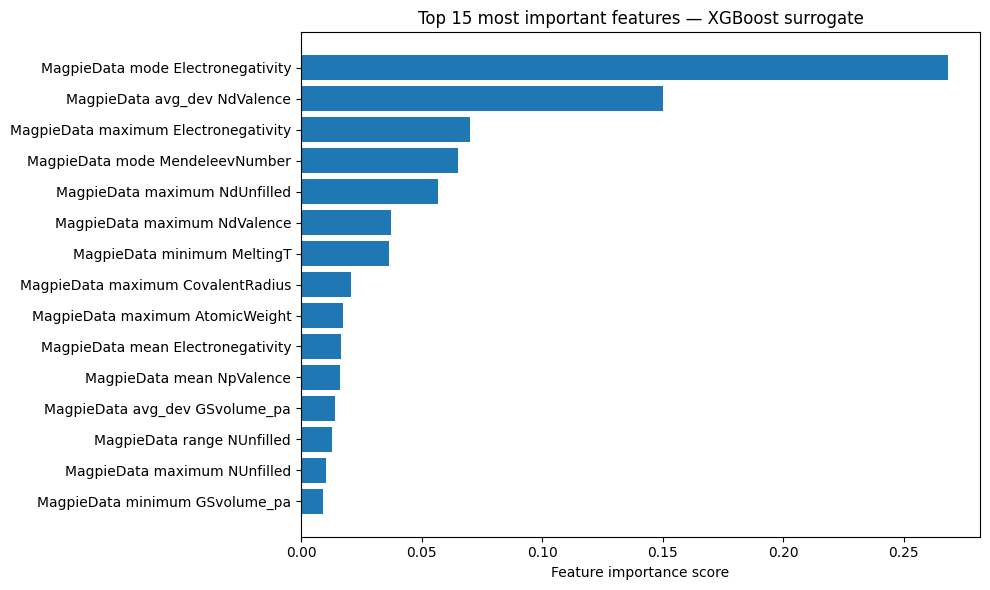

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# get feature importance scores
feature_names = ep.feature_labels() + ["nsites", "Li_fraction"]
importances = model.feature_importances_

# sort by importance
indices = np.argsort(importances)[::-1][:15]   # top 15

# plot
plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in indices[::-1]],
    importances[indices[::-1]]
)
plt.xlabel("Feature importance score")
plt.title("Top 15 most important features — XGBoost surrogate")
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 7 — Chemical Space Visualization
Project 134-dimensional feature space into 2D using UMAP
to understand dataset coverage and identify material families.

**Why UMAP over PCA:** UMAP preserves local neighbourhood structure —
chemically similar materials cluster together. PCA only captures
linear relationships and blurs chemical family boundaries.

**Parameters:** n_neighbors=15, min_dist=0.1, random_state=42

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Embedding shape: (4017, 2)


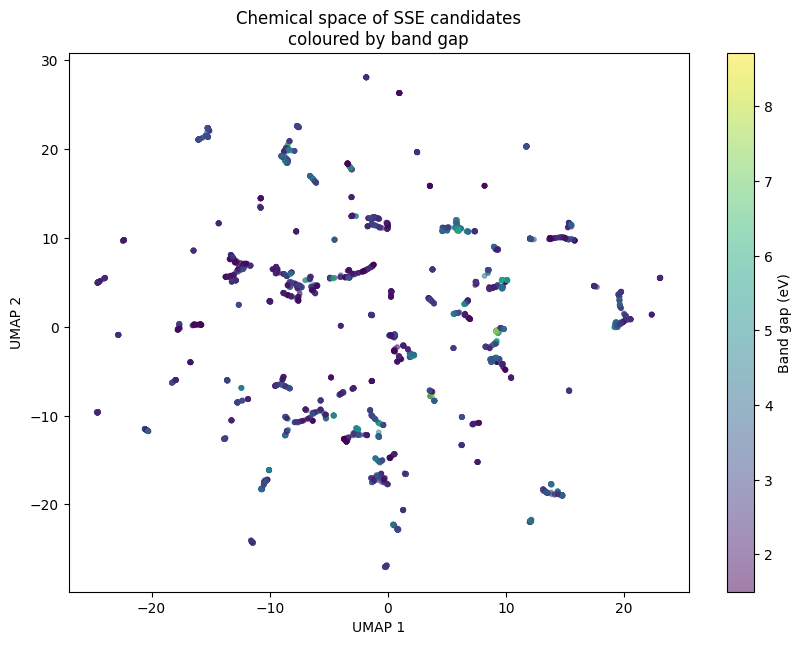

In [47]:
import umap

# screate and fit UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(x)

print(f"Embedding shape: {embedding.shape}")

# plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label="Band gap (eV)")
plt.title("Chemical space of SSE candidates\ncoloured by band gap")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.savefig(f"{RESULTS_PATH}/umap_chemical_space.png", dpi=150, bbox_inches="tight")
plt.show()